# Memória e Estado

Uma chamada ao modelo é isolada. Tudo o que ele parece lembrar está escrito no prompt daquela chamada ou ficou nos pesos durante o treino, e memória é o nome do conjunto de decisões sobre o que entra ali.

O notebook separa três coisas: o que veio do treino, o que vale para a execução atual e o que sobrevive ao fim dela, guardado em um arquivo. Os primeiros exemplos acompanham uma mesa de RPG, e os últimos, um assistente pessoal.

In [ ]:
# No Google Colab, descomente e rode uma vez (Ambiente de execução > GPU).
!pip install -q "agentkit @ git+https://github.com/silvaan/agentic-ai"

import json
from pathlib import Path

import pandas as pd
import torch

from agentkit import LLM

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
llm = LLM(MODEL_NAME, device=device, temperature=0.0, max_tokens=100)
print(llm.model)

## Memória paramétrica

Parte do que o modelo responde não vem do prompt. O treino ajustou bilhões de parâmetros sobre um corpus enorme, e o que ficou ali é consultado de graça em toda chamada. As duas perguntas abaixo têm a mesma forma e destinos diferentes.

In [ ]:
print(llm.invoke([{"role": "user", "content": "O que é um elétron? Responda em uma frase."}]))
print(llm.invoke([{"role": "user", "content": "Quem é o vilão da campanha que a Bia joga às terças?"}]))

A primeira resposta veio dos pesos e está certa. A segunda trata de uma campanha que nunca esteve no corpus de treino, e o modelo reconhece a lacuna e pede contexto. Essa memória é congelada na data do treino, não é editável em tempo de uso e não registra de onde cada afirmação veio.

## Memória de curto prazo

É o que vale para a execução atual e morre com ela. Aqui estão o histórico da conversa, as políticas que decidem o que cabe no contexto e o estado que o programa carrega enquanto executa.

### Histórico

O modelo não recebe um identificador de sessão nem consulta o que foi dito antes. As duas chamadas abaixo são independentes, e a segunda não recebe a primeira.

In [ ]:
SYSTEM = {"role": "system", "content": "Você ajuda a mestrar uma mesa de RPG. Responda em uma frase curta."}

print(llm.invoke([SYSTEM, {"role": "user", "content": "Minha personagem se chama Yara."}]))
print(llm.invoke([SYSTEM, {"role": "user", "content": "Como se chama minha personagem?"}]))

Nada foi esquecido, porque nada foi guardado. O primeiro tipo de memória de um chatbot é uma lista mantida pelo programa: cada rodada acrescenta a entrada do usuário e a resposta, e a chamada seguinte recebe a lista inteira.

In [ ]:
def chat(history: list[dict], message: str) -> str:
    """Executa um turno e modifica o histórico no lugar."""
    history.append({"role": "user", "content": message})
    answer = llm.invoke(history)
    history.append({"role": "assistant", "content": answer})
    return answer


TURNS = [
    "Sou o João e jogo como um arqueiro elfo.",
    "Na sessão passada o grupo entrou na caverna do norte.",
    "A Yara está com 12 pontos de vida.",
    "Ela guardou o Amuleto de Névoa na mochila.",
    "A próxima sessão é dia 14 de março.",
]

history = [SYSTEM.copy()]
for turn in TURNS:
    chat(history, turn)
pd.DataFrame(history)

In [ ]:
QUESTION = {"role": "user", "content": "Qual meu nome?"}
print(llm.invoke(history + [QUESTION]))

Com a lista inteira no prompt, o nome da personagem volta. Os papéis fazem parte do significado do histórico: `system` define o comportamento, `user` traz as entradas e `assistant` registra as respostas anteriores.

### Janela deslizante

O modelo recebe todas as mensagens de novo a cada turno, então o custo cresce com o histórico. A política mais simples é cortar pelo fim, mantendo a mensagem de sistema e as últimas mensagens.

In [ ]:
def recent_messages(history: list[dict], max_messages: int = 4) -> list[dict]:
    """Preserva a mensagem de sistema e devolve as últimas mensagens."""
    return [history[0], *history[1:][-max_messages:]]


window = recent_messages(history)
print(f"histórico: {len(history)} mensagens | janela: {len(window)} mensagens")
pd.DataFrame(window)

In [ ]:
print(llm.invoke(window + [QUESTION]))

A janela ficou com os dois últimos turnos, e o nome da personagem, dito no primeiro, saiu do contexto. O corte é cego: ele olha a posição e descarta com a mesma facilidade uma saudação e o dado que a próxima pergunta precisa.

### Sumarização progressiva

Em vez de descartar o começo, podemos criar uma representação compacta dele. A conversa vai entre marcas e a instrução vem depois dela, porque sem isso o modelo continua o diálogo em vez de resumi-lo. O resumo entra dentro da mensagem de sistema que já existe.

In [ ]:
def summarize(messages: list[dict]) -> str:
    """Resume um trecho de conversa preservando nomes, valores e datas."""
    conversation = "\n".join(f"{m['role']}: {m['content']}" for m in messages)
    return llm.invoke([{"role": "user", "content": (
        f"<conversa>\n{conversation}\n</conversa>\n\n"
        "Resuma a conversa acima em até cinco linhas, preservando nomes, lugares, eventos, valores e datas."
    )}], max_tokens=140)


summary = summarize(history[1:-4])
print(summary)

In [ ]:
summarized = [
    {"role": "system", "content": f"{SYSTEM['content']}\n\nResumo da conversa anterior:\n{summary}"},
    *history[-4:],
]
print(f"completo: {len(history)} mensagens | resumido: {len(summarized)} mensagens")

In [ ]:
CHECKS = [
    "Como me chamo?",
    "Qual é a minha classe?",
    "Onde o grupo entrou na sessão passada?",
    "Quando é a próxima sessão?",
]

pd.DataFrame([{
    "pergunta": check,
    "histórico completo": llm.invoke(history + [{"role": "user", "content": check}], max_tokens=60),
    "contexto resumido": llm.invoke(summarized + [{"role": "user", "content": check}], max_tokens=60),
} for check in CHECKS])

O histórico completo responde às quatro perguntas. O resumido acerta o lugar e a data, que estão nas mensagens preservadas, e perde o nome e a classe, ditos no primeiro turno.

A instrução do resumo mandava preservar nomes e a classe ficou de fora mesmo assim. Na pergunta do lugar, o contexto curto ainda acrescentou um combate que ninguém mencionou: comprimir decide o que perder e abre espaço para o modelo preencher o resto.

### Exercício 1

Converse cinco turnos com o assistente, colocando um dado importante no primeiro. Faça a mesma pergunta sobre esse dado três vezes: com o histórico completo, com a janela deslizante e com o contexto resumido.

Responda qual das três perdeu o dado e quantas mensagens cada uma levou ao prompt.

In [ ]:
# Seu código aqui

### Estado do agente

O histórico é uma parte do estado, e não o estado inteiro. O assistente também carrega o que a sessão já estabeleceu: onde o grupo está, quanta vida a personagem tem e o que ela leva na mochila.

In [ ]:
state = {
    "personagem": "Yara",
    "local": "caverna do norte",
    "vida": 12,
    "inventario": [],
    "messages": [],
}
state

In [ ]:
MASTER_TEMPLATE = """Você ajuda a mestrar uma mesa de RPG. Responda em uma frase curta.

Personagem: {personagem}
Local: {local}
Vida: {vida}
Inventário: {inventario}"""


def system_prompt(state: dict) -> dict:
    """Preenche o gabarito com o estado atual."""
    return {"role": "system", "content": MASTER_TEMPLATE.format(
        personagem=state["personagem"],
        local=state["local"],
        vida=state["vida"],
        inventario=", ".join(state["inventario"]) or "vazio",
    )}


print(system_prompt(state)["content"])

O estado é dado, e o prompt é texto. O gabarito acima faz a passagem de um para o outro, e é ele que decide o que da execução o modelo enxerga. A função abaixo faz o turno: recebe o estado, pergunta ao modelo e devolve o estado com a conversa acrescentada, na mesma forma do `chat` da primeira parte.

In [ ]:
def turn(state: dict, message: str) -> dict:
    """Faz um turno usando o estado como contexto e devolve o estado."""
    answer = llm.invoke([system_prompt(state), *state["messages"],
                         {"role": "user", "content": message}])
    state["messages"] += [{"role": "user", "content": message},
                          {"role": "assistant", "content": answer}]
    return state

In [ ]:
QUESTION = "Onde eu estou, como está minha vida e o que carrego?"

state = turn(state, QUESTION)
print(state["messages"][-1]["content"])

In [ ]:
state["vida"] = 8
state["local"] = "ponte quebrada"
state["inventario"].append("Amuleto de Névoa")

state = turn(state, QUESTION)
print(state["messages"][-1]["content"])
print(state["local"], "|", state["vida"], "de vida |", len(state["messages"]), "mensagens")

A mesma pergunta foi feita duas vezes e a resposta mudou, porque o prompt é montado a partir do estado e o estado mudou entre elas. As três linhas do meio são a mesa acontecendo, e o `turn` não precisa saber delas: ele lê o estado que encontrar.

### Exercício 2

As três linhas que mudaram o estado acima foram escritas à mão. Aqui quem escreve é o modelo: declare o estado como uma classe `GameState`, com `personagem`, `local`, `vida` e `inventario`, e para cada cena chame `llm.generate_structured` com o estado atual em JSON e a frase, substituindo o estado pelo objeto devolvido.

Responda o que o modelo mudou sem que a cena pedisse e o que aconteceu com o inventário na última, que não altera nada.

In [ ]:
from pydantic import BaseModel

SCENES = [
    "Yara sai da caverna do norte e chega à ponte quebrada.",
    "Uma flecha acerta a Yara e tira 4 pontos de vida.",
    "Ela encontra o Amuleto de Névoa entre as pedras e guarda na mochila.",
    "O grupo descansa a noite inteira em silêncio.",
]

In [ ]:
# Seu código aqui

### Sessões

O histórico da primeira parte era uma lista só, de uma conversa só. Um assistente atende várias pessoas ao mesmo tempo,
e cada conversa tem o seu histórico, então o que separa uma da outra é um identificador: cada sessão vira uma chave, e a
lista de mensagens daquela conversa fica guardada debaixo dela.

In [ ]:
CHAT_TEMPLATE = """Você é um assistente de uso geral. Responda em uma frase curta.

Data de hoje: {date}."""

TODAY = "2026-03-15"

sessions = {
    "a3f1": [
        {"role": "user", "content": "Meu voo para Recife é dia 20 de abril."},
        {"role": "assistant", "content": "Anotado: seu voo para Recife é no dia 20 de abril."},
        {"role": "user", "content": "Reservei o hotel perto da praia de Boa Viagem."},
        {"role": "assistant", "content": "Boa escolha, Boa Viagem fica a quinze minutos do aeroporto."},
    ],
    "b7c2": [
        {"role": "user", "content": "Estou escrevendo um artigo sobre energia solar."},
        {"role": "assistant", "content": "Posso ajudar com a estrutura, com fontes ou com a revisão do texto."},
    ],
    "c5d8": [],
}

pd.DataFrame([{"sessão": session_id, "mensagens": len(history), # historico da conversa
               "início": history[0]["content"] if history else "(vazia)"}
              for session_id, history in sessions.items()]) # aqui guarda o comportamento do modelo mas é montando apartir de um gabarato e n fica armazenado no sistema

A sessão guarda apenas as mensagens da conversa. A mensagem de sistema não é gravada: ela é montada a partir do gabarito
na hora da chamada e colocada na frente do histórico que a sessão tiver.

In [ ]:
def session_chat(sessions: dict, session_id: str, message: str) -> str: # => as mensagems de sistema sao montadas pela hora (NÃO SÃO ARMAZENADAS)
    """Procura o histórico pelo identificador da sessão e executa um turno nele.""" # vai ser como cada sessao tendo seu id
    history = sessions.setdefault(session_id, [])
    system = {"role": "system", "content": CHAT_TEMPLATE.format(date=TODAY)}
    history.append({"role": "user", "content": message})
    answer = llm.invoke([system, *history])
    history.append({"role": "assistant", "content": answer})
    return answer


RECAP = "Sobre o que estávamos falando?"

for session_id in sessions:
    print(session_id, "->", session_chat(sessions, session_id, RECAP))

In [ ]:
pd.DataFrame([{"sessão": session_id, "mensagens": len(history),
               "última resposta": history[-1]["content"]} # capitura a ultima resposta do agente e verifica se esta tudo de acordo
              for session_id, history in sessions.items()])

A mesma pergunta chegou a três sessões e voltou diferente em cada uma, inclusive na que estava vazia, e nenhuma viu o
histórico da outra. O identificador é a única coisa que decide isso.

O dicionário é o armazenamento mais simples que existe, e serve para enxergar o desenho: procurar pelo identificador,
executar o turno, guardar de volta. Trocá-lo por um arquivo JSON por sessão, ou por uma tabela de banco com o
identificador como chave, muda onde os dados ficam e não muda esse desenho. Enquanto ficam no dicionário, porém, nada
disso sobrevive ao fim do processo, e é esse o problema da parte seguinte.

## Memória de longo prazo

Tudo acima morre com o processo. Guardar algo para a próxima execução exige uma estrutura fora do modelo e fora da
memória do programa, e o mínimo que serve é um arquivo que o aluno pode abrir em qualquer editor. Os exemplos daqui em
diante são de um assistente pessoal, que atende a mesma usuária em execuções diferentes.

In [ ]:
MEMORY_PATH = Path("workspace/memory.json") # para manter a memoria indepedente da sessao -> memoria de longo prazo
MEMORY_PATH.parent.mkdir(parents=True, exist_ok=True) # cria uma pasta para q o modelo possa acessa a memoria de longo prazo

def load_memory() -> list[dict]:
    """Lê a memória do disco, ou devolve uma lista vazia na primeira execução.""" # aqui passamos oq o modelo irá quardar de memoria
    if MEMORY_PATH.exists():
        return json.loads(MEMORY_PATH.read_text(encoding="utf-8"))
    return [] # retorna a lista de memoria de longo prazo


def save_memory(memory: list[dict]) -> None: # permite o modelo acumular conhecimento
    """Grava a memória inteira no disco, em JSON legível."""
    MEMORY_PATH.write_text(json.dumps(memory, ensure_ascii=False, indent=2), encoding="utf-8") # grava no arquivo de memoria oq foi feito

Cada registro tem três campos: o tipo, uma chave que o identifica dentro do tipo e o conteúdo. Gravar com o mesmo tipo e a mesma chave substitui o conteúdo, e é essa regra que decide sozinha o comportamento das três memórias adiante.

In [ ]:
def remember(memory: list[dict], kind: str, key: str, content: str) -> None: # a memoria será uma lista, o tipo do q ele esta lembrando, o conteudo, e uma key para facilitar o acesso
    """Grava um registro, substituindo o que tiver o mesmo tipo e a mesma chave."""
    for item in memory:
        if item["type"] == kind and item["key"] == key:
            item["content"] = content
            return
    memory.append({"type": kind, "key": key, "content": content})


def recall(memory: list[dict], kind: str) -> list[dict]: # sensibilidade do retorno da memoria para o modelo
    """Devolve os registros de um tipo.""" # NÃO É GRAVADO JA TOKENIZADO PARA FACILITAR A MUDAÇA DE MODELOS OU DE IDENTIFICAR OQ É CADA COISA
    return [item for item in memory if item["type"] == kind]

A mensagem de sistema deixa de ser escrita à mão a cada consulta. Ela vira um gabarito com uma variável por tipo de
memória, e montar o prompt é preencher as variáveis com o que estiver gravado no momento.

In [ ]:
MEMORY_TEMPLATE = """Você é um assistente pessoal. Responda em uma frase curta.

Fatos conhecidos:
{semantic}

Registros anteriores:
{episodic}

Procedimentos a seguir:
{procedural}""" # passa a ser um gabarito para o modelo e começa a perder a necessidade de precisar passar o system_prompt na mão


def bullets(items: list[dict]) -> str:
    """Formata registros como linhas para entrar no gabarito.""" # separa cada registro de memoria para n fica tudo bagunçado
    return "\n".join(f"- {item['key']}: {item['content']}" for item in items) or "(nenhum)"


def system_message(memory: list[dict]) -> dict:
    """Preenche o gabarito com a memória gravada.""" # chama oq esta na memoria de longo prazo e mescla com o gabarito para o modelo se adequar melhor
    return {"role": "system", "content": MEMORY_TEMPLATE.format(
        semantic=bullets(recall(memory, "semantic")),
        episodic=bullets(recall(memory, "episodic")),
        procedural=bullets(recall(memory, "procedural")),
    )}


print(system_message([])["content"]) # a MEMORY TEMPLATE q antes seria o system prompt para o modelo passa a ser um gavbarito caverão para qualquer modelo q tenha acesso a memoria possa acessar e montar o proprio promp

Com a memória vazia, as três variáveis aparecem como `(nenhum)`. As três partes seguintes preenchem uma de cada vez, e a
mesma função monta o prompt em todas elas.

### Memória semântica

A memória semântica guarda o que é verdade sobre a usuária, sem registro de quando foi aprendido. A chave é o nome do
campo, então o mesmo fato tem uma versão só, sempre a última.

In [ ]:
memory = load_memory() # guarda apenas oq é verdadeiro sobre o usuario => sempre uma informação só terá uma informação valida (the last)
remember(memory, "semantic", "nome", "Maria")
remember(memory, "semantic", "profissao", "arquiteta em um escritório de reformas")
remember(memory, "semantic", "cidade", "Recife")
remember(memory, "semantic", "cidade", "Natal") # em modelos maiores ele monta uma lista injeta direito no contexto em caso de muitas infos faz um RAG
save_memory(memory) # em modelo maiores tem como se fosse um metodo q revisa para casa de atulizar informações
pd.DataFrame(recall(memory, "semantic")) # apenas para visualizar as coisas

In [ ]:
system = system_message(memory)
print(system["content"])
print(llm.invoke([system, {"role": "user", "content": "Quem sou eu e em que cidade eu moro?"}])) # o modelo vai buscar por essa lista no caso, ja q são poucas infos

A `cidade` foi gravada duas vezes e a tabela tem uma linha só, com o valor mais recente. A atualização é propriedade da
estrutura: como a chave é o nome do campo, o fato tem uma versão só, e foi Natal que chegou à resposta.

### Memória episódica

A memória episódica guarda o que aconteceu, e responde a outra pergunta: o que já foi feito. A chave é a data, então dois
episódios diferentes nunca colidem e a lista cresce.

In [ ]:
remember(memory, "episodic", "2026-02-10", "Pediu um roteiro de três dias em Salvador e escolheu a opção com menos deslocamento.")
remember(memory, "episodic", "2026-03-02", "Revisou o texto de apresentação do escritório e aprovou a segunda versão.")
save_memory(memory) # nesse caso como o epsidio é gravado pela data ele fica em uma memoria de longo prazo
pd.DataFrame(recall(memory, "episodic"))

In [ ]:
print(llm.invoke([system_message(memory),
                  {"role": "user", "content": "O que eu pedi em fevereiro?"}]))

Os dois episódios convivem, porque as chaves são datas diferentes e nada colidiu. A mesma função de escrita produziu o
comportamento oposto ao da parte anterior, e o que mudou foi só a escolha da chave. A resposta trouxe o registro de
fevereiro, que é o que a pergunta pedia.

### Memória procedural

A memória procedural guarda como fazer. Ela entra no prompt como instrução, e não como dado a consultar, e é essa a
diferença de tratamento em relação às outras duas.

In [ ]:
remember(memory, "procedural", "reunioes", "Toda reunião é marcada com quinze minutos de folga antes e depois.")
remember(memory, "procedural", "respostas", "Resposta longa vai em tópicos, nunca em um parágrafo único.")
save_memory(memory)
pd.DataFrame(recall(memory, "procedural"))

In [ ]:
system = system_message(memory)
print(system["content"])
print(llm.invoke([system, {"role": "user", "content": "Como eu devo marcar uma reunião na agenda?"}]))

A resposta seguiu a regra da usuária, e nenhuma consulta foi feita para isso. É a diferença de tratamento entre os três
tipos: fato e episódio entram como dado, para o modelo consultar, e procedimento entra como instrução, para o modelo
obedecer.

### Exercício 3

Escreva `search(texts, query, k=3)`, que conta quantas palavras da pergunta aparecem em cada texto e devolve os três de maior contagem. Responda às duas perguntas colocando no prompt apenas os textos que a busca trouxe.

Responda qual texto a segunda pergunta precisava e a busca não trouxe, e por quê.

In [ ]:
MEMORIES = [
    "Em 8 de janeiro pediu a lista de materiais para a reforma da cozinha e aprovou o orçamento.",
    "Em 19 de janeiro montou o cronograma da obra do apartamento da Zona Sul.",
    "Em 3 de fevereiro comparou três fornecedores de porcelanato e ficou com o mais barato.",
    "Em 10 de fevereiro pediu um roteiro de três dias em Salvador e escolheu a opção com menos deslocamento.",
    "Em 21 de fevereiro reescreveu a proposta comercial do escritório em tom mais direto.",
    "Em 2 de março revisou o texto de apresentação do escritório e aprovou a segunda versão.",
    "Em 24 de março listou as plantas que faltavam entregar ao cliente da loja.",
    "Em 5 de abril escolheu a paleta de cores do quarto das crianças.",
]

QUESTIONS = [
    "O que eu decidi sobre a reforma da cozinha?",
    "Quando eu viajei?",
]

In [ ]:
# Seu código aqui

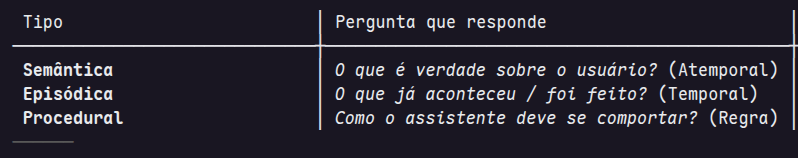